In [3]:
# 이미지 탐지 결과를 DataFrame에 저장해서 CSV로 저장한 후 이를  -> 요약 통계 처리
!pip install ultralytics opencv-python

In [4]:
import os
import pandas as pd
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
img_dir = 'images'

img_paths = [
    os.path.join(img_dir, f)
    for f in os.listdir(img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
print(img_paths)

records = []

for path in img_paths:
  results = model(path, conf=0.25, verbose=False)[0]    # 단일 이미지 추론
  boxes = results.boxes
  names = results.names
  # print(names)

  if len(boxes) == 0:
    records.append({
        'image': os.path.basename(path),
        'object_count': 0,
        'classes': '',
        'avg_confidence': 0.0
    })
    continue

  # cpu() : pyrotch텐서로 반환된 값을 cpu 메모리로 옮겨 numpy 배열로 변환
  cls_id = boxes.cls.cpu().numpy().astype(int)    # 탐지된 객체들의 클래스 id(정수 라벨 번호)
  print('cls_id : ', cls_id)
  confs = boxes.conf.cpu().numpy()
  print('confs : ', confs)

  classes = [names[i] for i in cls_id]
  print('classes : ', classes) # ['person', 'person', 'handbag', 'person']
  avg_conf = float(confs.mean())    #

  records.append({
      'image':os.path.basename(path),
      'object_count': len(cls_id),
      'classes':','.join(sorted(set(classes))),
      'avg_confidence': avg_conf
  })

['images/image3.png', 'images/image1.jpg', 'images/image2.jpeg']
cls_id :  [0 0 3 0 0 2]
confs :  [    0.89472     0.88528     0.84669     0.69414     0.28265     0.25905]
classes :  ['person', 'person', 'motorcycle', 'person', 'person', 'car']
cls_id :  [0 0]
confs :  [    0.81587     0.46298]
classes :  ['person', 'person']
cls_id :  [ 0  0 26  0]
confs :  [    0.82473     0.72216     0.43466     0.30244]
classes :  ['person', 'person', 'handbag', 'person']


In [5]:
# records로 DataFrame에 저장
df = pd.DataFrame(records)
print(df)

df.to_csv('yolo6report.csv', index=False, encoding='utf-8-sig')
print('csv로 저장 성공 ~~~')

         image  object_count                classes  avg_confidence
0   image3.png             6  car,motorcycle,person        0.643755
1   image1.jpg             2                 person        0.639423
2  image2.jpeg             4         handbag,person        0.570998
csv로 저장 성공 ~~~


         image  object_count                classes  avg_confidence
0   image3.png             6  car,motorcycle,person        0.643755
1   image1.jpg             2                 person        0.639423
2  image2.jpeg             4         handbag,person        0.570998
         image  object_count                classes  avg_confidence
0   image3.png             6  car,motorcycle,person        0.643755
1   image1.jpg             2                 person        0.639423
2  image2.jpeg             4         handbag,person        0.570998
총 이미지 수 : 3
총 탐지 갯 수 : 12
전체 confidence 평균 : <bound method Series.mean of 0    0.643755
1    0.639423
2    0.570998
Name: avg_confidence, dtype: float64>
클래스 별 등장 이미지 수 : 
  car: 1
  motorcycle: 1
  person: 3
  handbag: 1
       object_count  avg_confidence
count           3.0        3.000000
mean            4.0        0.618059
std             2.0        0.040813
min             2.0        0.570998
25%             3.0        0.605211
50%             4.

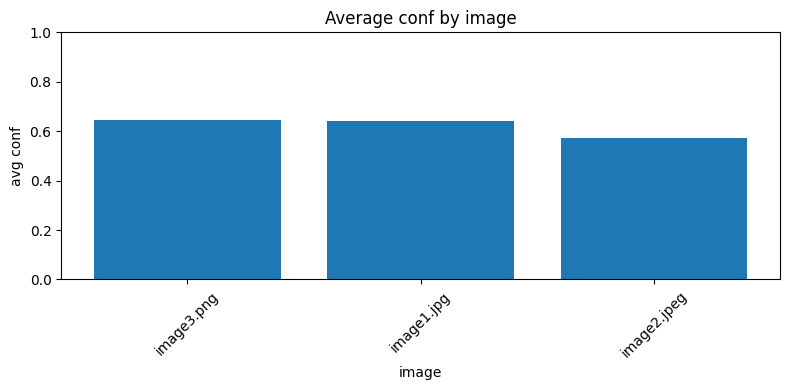

In [12]:
from numpy import fill_diagonal
# CSV 로딩
mydf = pd.read_csv('yolo6report.csv')
print(mydf)

num_images = len(df)
total_objects = df['object_count'].sum()    # 탐지 객체 총 갯수 CSV 로딩
mydf = pd.read_csv('yolo6report.csv')
print(mydf)

num_images = len(df)
total_objects = df['object_count'].sum()    # 탐지 객체 총 갯수
# print('total objects : ', total_objects)

# 전체 confidence 평균
overall_avg_conf = mydf.loc[mydf['avg_confidence'] > 0,
                            'avg_confidence'].mean if total_objects > 0 else 0.0

print(f'총 이미지 수 : {num_images}')
print(f'총 탐지 갯 수 : {total_objects}')
print(f'전체 confidence 평균 : {overall_avg_conf}')

class_counts = {}
for cls_str in mydf['classes']:
  if cls_str:
    for c in cls_str.split(','):
      class_counts[c] = class_counts.get(c, 0) + 1  # 나눠진 리스트를 하나씩 반복


print('클래스 별 등장 이미지 수 : ')
for k, v in class_counts.items():
  print(f'  {k}: {v}')

print(mydf[['object_count', 'avg_confidence']].describe())

max_row = mydf.loc[mydf['object_count'].idxmax()]
print('가장 많이 감지된 객체는 : ', max_row)

# 평균 신뢰도 막대 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(mydf['image'], mydf['avg_confidence'])
plt.title('Average conf by image')
plt.xlabel('image')
plt.ylabel('avg conf')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()